# Simulating Country Interactions Based on Hungarian Data

In [1]:
# number of countries in the simulation (including the original dataset):
N_countries = 5

In [ ]:
from utils import data_path, cost_params, week_numbers
from utils import change_generator_p_nom_max, change_storage_p_nom_max
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import copy

import pypsa

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create analyzed dates

In [3]:
dates = []
start_date = pd.to_datetime('2000-01-01')
for week in week_numbers.values():
    s = start_date + pd.Timedelta(weeks=week-1)
    e = s + pd.Timedelta(days=6, hours=23)
    dates.append(pd.date_range(start=s ,end=e, freq='h').to_list())

# Import original data

In [4]:
with pd.ExcelFile(data_path) as xls:
    data = {'country_0': {
        'potentials_generator': pd.read_excel(xls, sheet_name='potentials_generator', index_col=0, na_values='None'),
        'potentials_storage':   pd.read_excel(xls, sheet_name='potentials_storage', index_col=0, na_values='None'),
        'costs_generator':      pd.read_excel(xls, sheet_name='costs_generator', index_col=0, na_values='None').to_dict(),
        'costs_storage':        pd.read_excel(xls, sheet_name='costs_storage', index_col=0, na_values='None').to_dict(),
        'profile_wind':         pd.read_excel(xls, sheet_name='profile_wind', index_col=0, header=None, names=list(week_numbers.keys())),
        'profile_PV':           pd.read_excel(xls, sheet_name='profile_PV', index_col=0, header=None, names=list(week_numbers.keys())),
        'demand':               pd.read_excel(xls, sheet_name='demand').values.ravel()
    }}
# simulation parameters
country_params = ['potentials_generator', 'potentials_storage', 'costs_generator', 'costs_storage', 'profile_wind', 'profile_PV', 'demand']

### Generate new countries 
Modifications:
- Maximum potential of generators: 13 random --> choose 2-3-4-4 randomly from the following power plants types:
    - `small` ($10-100$ MWh), 
    - `medium` ($100-1000$ MWh),
    - `large` ($1000-2500$ MWh),
    - `non-existing` ($0$ MWh)
- Storages: Two random ($100-3000$ MWh)

In [5]:
pg='potentials_generator'
ps = 'potentials_storage'
for id in range(1, N_countries):
    c=f'country_{id}'
    data[c] = copy.deepcopy(data['country_0'])
    data[c][pg].loc['p_nom_max'] = change_generator_p_nom_max(seed=137+id)
    data[c][pg].loc['p_nom_max'] = change_generator_p_nom_max(seed=137+id)
    data[c][pg].loc['p_nom_min', 'Nuclear'] = 0.9 * data[c][pg].loc['p_nom_max', 'Nuclear']
    data[c][ps].loc['p_nom_max'] = change_storage_p_nom_max(seed=137+id)
    data[c]['demand'] *= np.random.default_rng(seed=137+id).uniform(0.8, 1.2)

- Create random connection between countries with $100-3000$ MWh tranding capacity
    - the direction of trading is varied by a factor between `[0.5, 1.5]`

In [6]:
np.random.seed(137)
tri = np.triu(np.random.randint(100, 3000, size=(N_countries, N_countries)), k=1)
mask = np.random.randint(0, 2, size=(N_countries, N_countries))
trading_connections = tri * mask

variation = np.random.uniform(0.5, 1.5, size=(N_countries, N_countries))
trading_connections += (trading_connections.T * variation).astype(int)

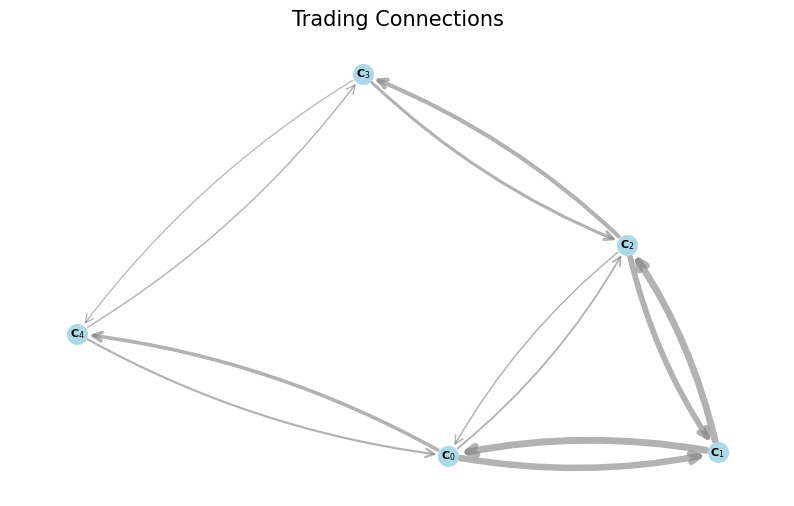

In [7]:
# Visualize the trading connections
G = nx.from_numpy_array(trading_connections, create_using=nx.DiGraph)
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=10)  
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(weights) if weights else 1
norm_weights = [5 * (w / max_weight) for w in weights]
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=norm_weights, arrowstyle='->', arrowsize=15,
                       edge_color='gray', alpha=0.6, connectionstyle='arc3,rad=0.1')
labels = {i: rf"C$_{i}$" for i in range(N_countries)}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
plt.title("Trading Connections", fontsize=15)
plt.axis('off')
plt.show()

#### Changing cost paramteres

In [8]:
# here you can change the parameters of the countries, for example:
#change_costs(data['country_1']['costs_generator'], ['Solar'], ['operation'], 
#                         low=0.95, high=1.05, size=data['country_1']['demand'].shape)

# PyPSA - Network & Optimizations

In [9]:
# Build the PyPSA network
network = pypsa.Network(name='Connected Network')
network.set_snapshots([item for sublist in dates for item in sublist])
network.add(class_name='Carrier', name='AC')

# Add buses, loads, generators, storage units, and links based on the data for each country
for country, c_data in data.items():
    network.add(class_name="Bus", name=country, carrier="AC")

    network.add("Load", 
                name=f"{country}_demand", 
                bus=country, 
                p_set=c_data['demand'])

    for tech in c_data['potentials_generator'].keys():
        if tech == 'Solar':
            p_max_pu = np.repeat(c_data['profile_PV'].values, 7, axis=1).flatten('F')
        elif tech == 'Wind Onshore':
            p_max_pu = np.repeat(c_data['profile_wind'].values, 7, axis=1).flatten('F')
        else:
            p_max_pu = 1

        network.add(class_name="Generator",
                    name=f"{country}_{tech}",
                    nicename=tech,
                    bus=country,
                    p_nom_extendable=True,
                    p_nom_max=c_data['potentials_generator'][tech]['p_nom_max'],
                    capital_cost=c_data['costs_generator'][tech]['capital'],
                    marginal_cost=sum([c_data['costs_generator'][tech][k] for k in cost_params[1:]]),
                    p_max_pu=p_max_pu,
                    ramp_limit_up=c_data['potentials_generator'].loc['ramp_up'][tech],
                    ramp_limit_down=c_data['potentials_generator'].loc['ramp_down'][tech])

    
    for tech in c_data['potentials_storage'].keys():
        network.add(class_name="StorageUnit",
                    name=f"{country}_{tech}",
                    bus=country,
                    p_nom_extendable=True,
                    p_nom_max=c_data['potentials_storage'][tech]['p_nom_max'],
                    capital_cost=c_data['costs_storage'][tech]['capital'],
                    marginal_cost=sum([c_data['costs_storage'][tech][k] for k in cost_params[1:]]))

# Add trading connections as Links
for idx, cap in enumerate(trading_connections.flatten()):
    if cap > 0 and idx // N_countries != idx % N_countries:
        countries = list(data.keys())
        c_from = countries[idx // N_countries]
        c_to = countries[idx % N_countries]
        network.add(class_name="Link",
                    name=f"Link_{c_from.split('_')[1]}_{c_to.split('_')[1]}",
                    bus0=c_from, bus1=c_to,
                    p_nom=float(cap), p_nom_extendable=False,
                    p_min_pu=0, p_max_pu=1,
                    marginal_cost=1)

In [10]:
# Optimize the network
network.sanitize()
network.optimize(solver_name='highs', 
                 solver_options={'presolve': 'on', 
                                 'threads': 8,
                                 'time_limit': 3600}
                )

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Assigned colors to 1 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - presolve: on
 - threads: 8
 - time_limit: 3600
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 80.79it/s]
INFO:linopy.io: Writing time: 1.01s


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-f6toe85k has 241268 rows; 71979 cols; 568206 nonzeros
Coefficient ranges:
  Matrix  [5e-05, 1e+00]
  Cost    [1e-01, 2e+04]
  Bound   [0e+00, 0e+00]
  RHS     [1e+01, 6e+03]
Presolving model
124900 rows, 58747 cols, 380515 nonzeros 0s
Dependent equations search running on 9399 equations with time limit of 36.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 36.00s)
124882 rows, 58729 cols, 380461 nonzeros 0s
Presolve reductions: rows 124882(-116386); columns 58729(-13250); nonzeros 380461(-187745) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 3360(7.62772e+06) 0.8s
      21024     7.4408118160e+07 Pr: 11202(3.44229e+08); Du: 0(3.87165e-08) 6.5s
      23238     7.9016034673e+07 Pr: 15617(4.41771e+07); Du: 0(3.87165e-08) 13.1s
      26312     9.2036531967e+07

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 71979 primals, 241268 duals
Objective: 3.60e+08
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-f6toe85k
Model status        : Optimal
Simplex   iterations: 247124
Objective value     :  3.6037593527e+08
P-D objective error :  6.4008151595e-14
HiGHS run time      :       1138.21


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [11]:
# Save network to csv
#network.export_to_csv_folder("data/results")
# Save network to nc file
_ = network.export_to_netcdf("data/connected_power_network.nc")

INFO:pypsa.network.io:Exported network 'Connected Network' saved to 'data/connected_power_network.nc contains: links, carriers, loads, storage_units, sub_networks, buses, generators
